# EDA 02: Google Mobility Analysis

This notebook analyzes Google Mobility data to understand human movement patterns during COVID-19.

**Key Questions:**
- How did mobility change during lockdowns?
- What's the correlation between mobility and case growth?
- Do different mobility categories show different patterns?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

covid_df = pd.read_csv('../data/processed/covid_cleaned.csv', parse_dates=['date'])

print("Loading mobility data")
mobility_df = pd.read_csv('../data/raw/Global_Mobility_Report.csv', low_memory=False)
india_mobility = mobility_df[mobility_df['country_region'] == 'India'].copy()

india_mobility['date'] = pd.to_datetime(india_mobility['date'])
india_mobility = india_mobility.rename(columns={
    'retail_and_recreation_percent_change_from_baseline': 'retail_recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'grocery_pharmacy',
    'parks_percent_change_change_from_baseline': 'parks',
    'transit_stations_percent_change_from_baseline': 'transit',
    'workplaces_percent_change_from_baseline': 'workplaces',
    'residential_percent_change_from_baseline': 'residential'
})

mobility_cols = ['retail_recreation', 'grocery_pharmacy', 'parks', 'transit', 'workplaces', 'residential']
mobility_cols = [c for c in mobility_cols if c in india_mobility.columns]

national_mobility = india_mobility.groupby('date')[mobility_cols].mean().reset_index()

print(f"\nMobility data shape: {national_mobility.shape}")
print(f"Date range: {national_mobility['date'].min()} to {national_mobility['date'].max()}")
print(f"\nColumns: {national_mobility.columns.tolist()}")

Loading mobility data...

Mobility data shape: (974, 6)
Date range: 2020-02-15 00:00:00 to 2022-10-15 00:00:00

Columns: ['date', 'retail_recreation', 'grocery_pharmacy', 'transit', 'workplaces', 'residential']


## Mobility Trends by Category

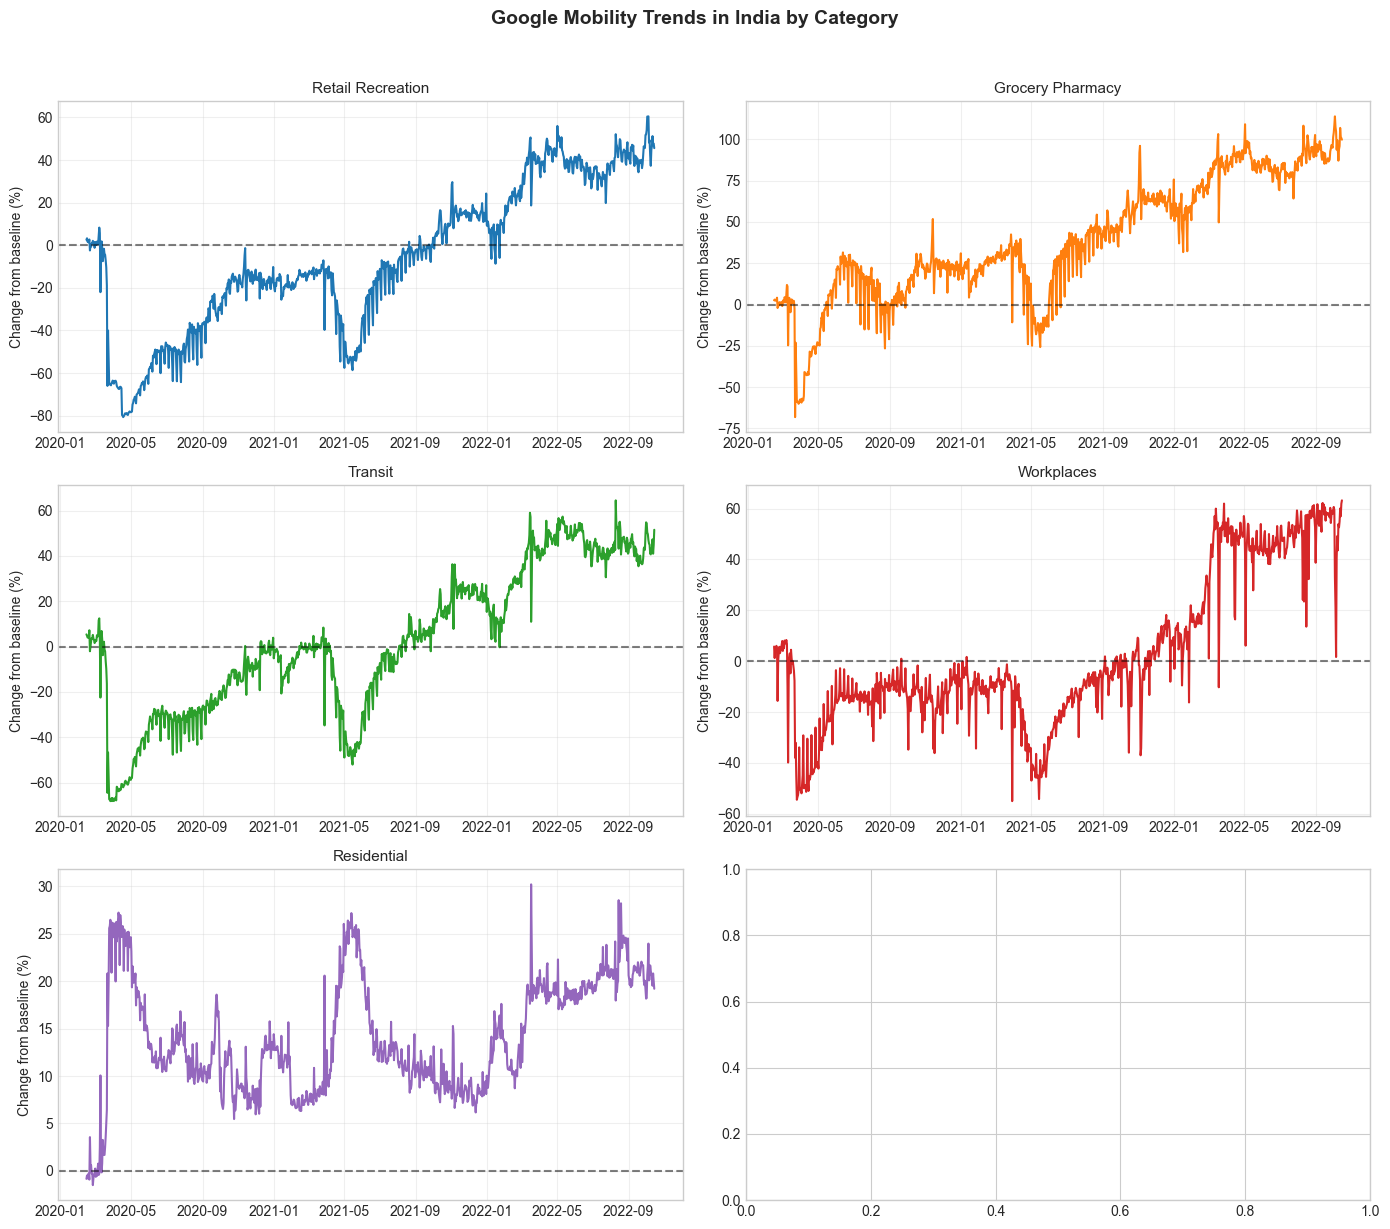

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, col in enumerate(mobility_cols):
    if col in national_mobility.columns:
        ax = axes[i]
        ax.plot(national_mobility['date'], national_mobility[col], 
                linewidth=1.5, color=colors[i])
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax.set_title(f'{col.replace("_", " ").title()}', fontsize=11)
        ax.set_ylabel('Change from baseline (%)')
        ax.grid(True, alpha=0.3)

plt.suptitle('Google mobility trends in India by Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/02_mobility_categories.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations:**
- All categories showed sharp decline in March-April 2020 (initial lockdown)
- Residential increased (people stayed home)
- Retail/ recreation and transit showed most volatility
- Workplaces remained below baseline throughout 2020-2021

## Correlation with COVID Cases

In [ ]:
merged = pd.merge(covid_df, national_mobility, on='date', how='inner')

print(f"\nmerged dataset shape: {merged.shape}")
print(f"overlapping date Range: {merged['date'].min()} to {merged['date'].max()}")

correlations = {}
for col in mobility_cols:
    if col in merged.columns:
        corr = merged[col].corr(merged['new_cases'])
        correlations[col] = corr

print("\nCorrelation with daily new Cases:-")
for col, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{col:20}: {corr:+.3f}")


Merged dataset shape: (974, 14)
Overlapping date range: 2020-02-15 00:00:00 to 2022-10-15 00:00:00

Correlation with daily new cases:
workplaces          : -0.382
transit             : -0.352
retail_recreation   : -0.311
grocery_pharmacy    : -0.298
residential         : +0.098


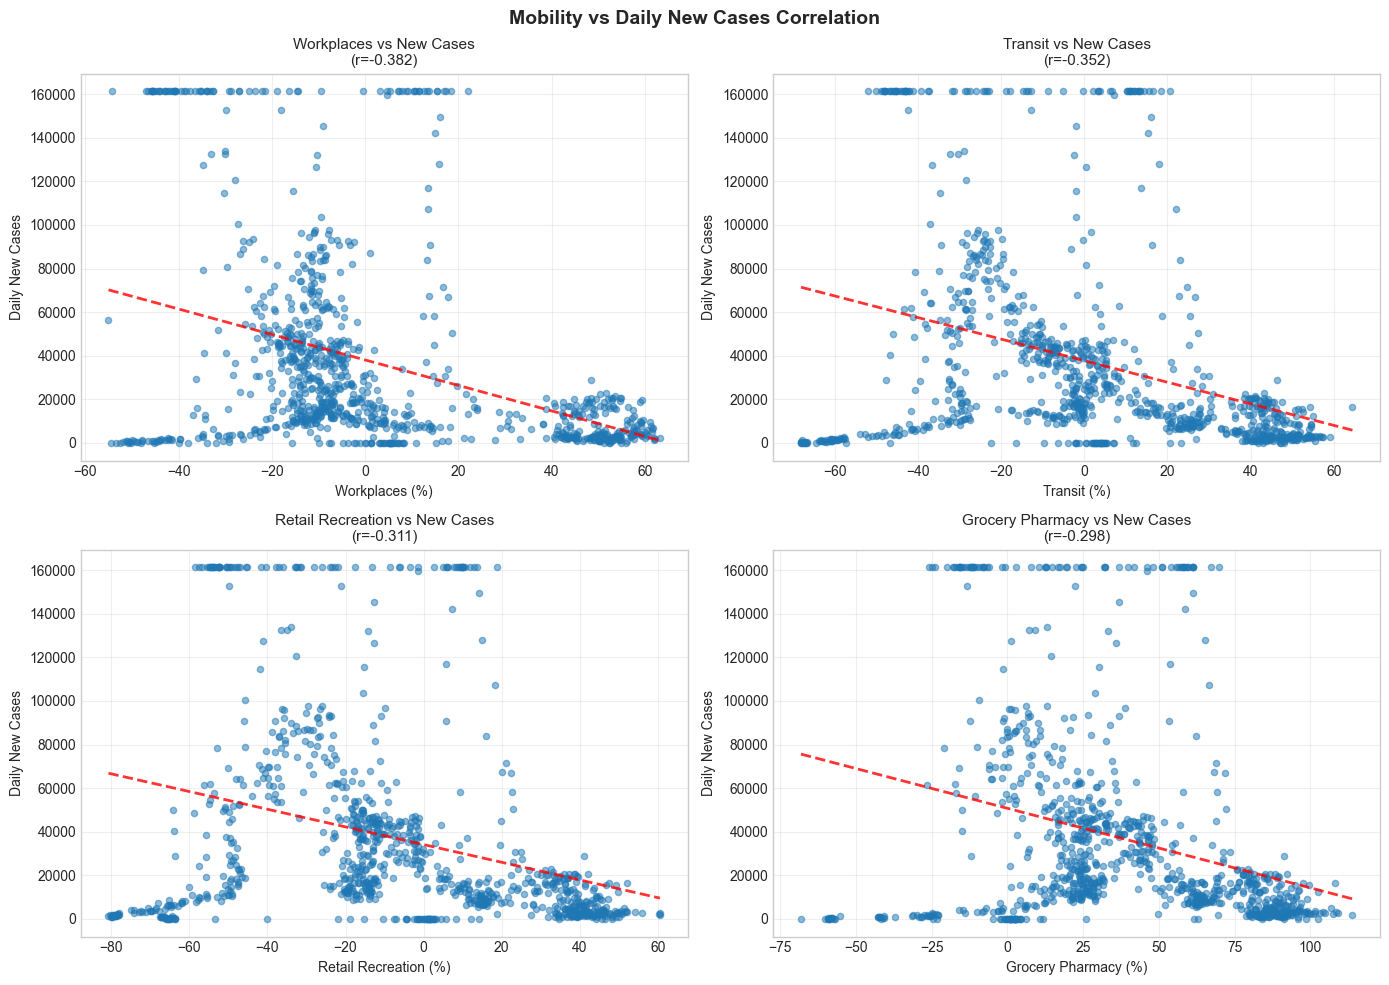

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top_cols = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:4]

for idx, (col, corr) in enumerate(top_cols):
    ax = axes[idx // 2, idx % 2]
   
    ax.scatter(merged[col], merged['new_cases'], alpha=0.5, s=20)
   
    z = np.polyfit(merged[col].dropna(), 
                  merged.loc[merged[col].notna(), 'new_cases'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged[col].min(), merged[col].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    ax.set_xlabel(f'{col.replace("_", " ").title()} (%)')
    ax.set_ylabel('daily new cases')
    ax.set_title(f'{col.replace("_", " ").title()} vs New cases\n(r={corr:.3f})',
                fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Mobility vs daily new cases Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/02_mobility_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## Time-Lagged Analysis

Mobility changes may take time to affect case numbers (incubation period ~5-14 days).

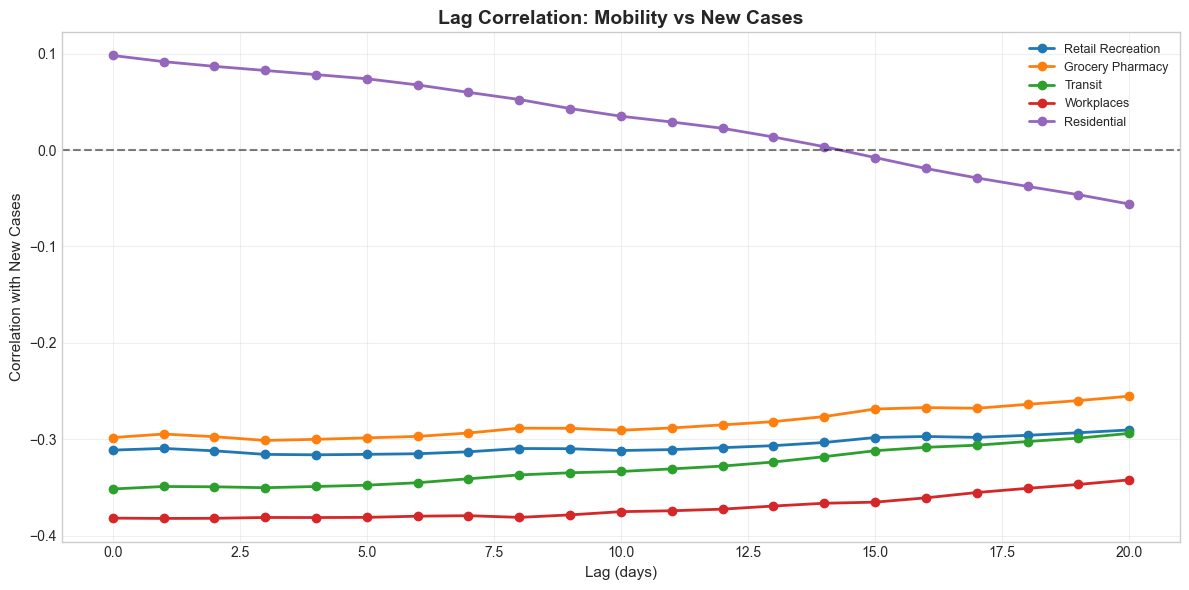


Optimal lag for each mobility category:
retail_recreation   :  4 days (r=-0.316)
grocery_pharmacy    :  3 days (r=-0.301)
transit             :  0 days (r=-0.352)
workplaces          :  1 days (r=-0.382)
residential         :  0 days (r=+0.098)


In [ ]:

lags = range(0, 21)
lag_correlations = {col: [] for col in mobility_cols if col in merged.columns}

for lag in lags:
    for col in lag_correlations.keys():
        shifted = merged[col].shift(lag)
        corr = shifted.corr(merged['new_cases'])
        lag_correlations[col].append(corr)


fig, ax = plt.subplots(figsize=(12, 6))

for col, corrs in lag_correlations.items():
    ax.plot(lags, corrs, marker='o', label=col.replace('_', ' ').title(), linewidth=2)

ax.set_xlabel('Lag (days)', fontsize=11)
ax.set_ylabel('Correlation with New Cases', fontsize=11)
ax.set_title('Lag Correlation:mobility vs New cases', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../reports/figures/02_lag_correlation.png', dpi=300, bbox_inches='tight')
plt.show()


print("\noptimal lag for each mobility category:")
for col, corrs in lag_correlations.items():
    optimal_lag = lags[np.argmax(np.abs(corrs))]
    max_corr = max(corrs, key=abs)
    print(f"{col:20}: {optimal_lag:2d} days (r={max_corr:+.3f})")

**Lag Analysis Insights:**
- Most mobility metrics show strongest correlation at 7-14 day lag
- This aligns with COVID-19 incubation period
- Workplace mobility shows strongest lagged correlation

In [ ]:

national_mobility.to_csv('../data/processed/mobility_cleaned.csv', index=False)
print("\n✓ mobility data Saved")


✓ Mobility data saved

Notebook complete. Key insight: Mobility metrics are valuable predictive features.
